In [6]:
"""
    MoM2D(xs, ys, xe, ye, ϕ)
    
    Computes charge distribution for 2D electrostatics by MOM

    Arguments:
    xs = x-coordinate for starting points
    ys = y-coordinate for starting points
    xe = x-coordinate for ending points
    ye = y-coordinate for ending points
    ϕ = the potential

    Returns
    σ = charge density for each element
    q = total charge on each element

"""

function MoM2D(xs, ys, xe, ye, ϕ)
   
    xobs = 0.5.*(xs + xe)    # Observation points
    yobs = 0.5.*(ys + ye)
    
    h = sqrt.((xe-xs).^2  + (ye - ys).^2)  # Length of elements  #distancia euclidiana en 2d para 2 puntos
    #so seria la distancia o el length de un elemento
    
    A = zeros(Float64, length(xs),length(xs))
    
    
    #'s' is is used to determine the fraction of the line segment's length that 
    #contributes to the electric potential at each observation point. 
    #The formula used here is derived from the principle of linear charge density.
    for k in eachindex(xs)
        s = ( (xobs .- xs[k])*(xe[k] .- xs[k])
            + (yobs .- ys[k])*(ye[k] .- ys[k]))./h[k]^2;
        
        #'d' calculates the distance between each observation point and the line segment, 
        #taking into account the contribution of the line segment's electric potential to the observation point. The formula used here is derived from the principle of superposition of electric fields.
        #The convert function is used here to ensure that the input to sqrt is a complex number, 
        #since there is a possibility of taking the square root of a negative number. 
        #The real function is used to extract the real part of the resulting complex number
        #The 1e-24 term is added to prevent division by zero in the subsequent calculations.
           
        d = real(sqrt.(convert.(Complex{Float64}, (xobs .- xs[k]).^2 + (yobs .- ys[k]).^2 - s.^2 .* h[k]^2 .+ 1e-24)))
        # 1e-24 is a simple hack to avoid dealing with ξe/d blowing up to infinity for d=0
        # note that d.*atan.(ξe./d) = 0 for d = 0 (analytically)
        # same is true for x*ln (x^2 + d^2)

        # 's' is a scalar value that represents the position of the obs point on the element ḱ' 
        #'ξs' scalar value that represents the starting position of element 'k'
        #  along the line connecting its two endpoints
        
        ξs = -s.*h[k]
        
        # 'ξe' will be a scalar value that represents the ending position of element k along
        #the line connecting its two endpoints.
        ξe = (1 .- s).*h[k]
        
        #ξs = distance along the line segment from the starting point to the observation point
        #ξe = distance along the line segment from the end point to the observation point
        
        # temp is a vector containing the contributions from each observation point to 
        #the charge density at the center of the current line segment. 
        temp = 0.5*ξe.*log.(ξe.^2 + d.^2) - ξe + d.*atan.(ξe./d) - 
            (0.5*ξs.*log.(ξs.^2 + d.^2) - ξs + d.*atan.(ξs./d))
        A[:, k] = -temp[:]/(2*π*8.854187)        
    end
    
    #These lines solve the linear system Aσ = ϕ to obtain the charge density σ at 
    #the center of each line segment. It then computes the total charge on each 
    #line segment q by multiplying σ with the length of the corresponding line segment h. 
    #Finally, the function returns the vectors q and σ.
    
    σ = (A\ϕ)      # Charge density   #parece que el '\' es sinónimo de hacer inversso de A para resolver sistema de ecuaciones
    q = h.*σ       # Charge per element
    return q, σ
end



MoM2D (generic function with 1 method)

In [47]:
"""
    get_capacitance(a, w, n)
    
    Arguments:
    a = separation distance between capacitor plates
    w = width of capacitor plate
    n = number of unknowns

    Returns:
    c = capacitance

"""

function get_capacitance(a, w, n)
    nh =  round(Int64,n/2) # Number of elements on each plate
    h =  w/nh # Length of the elements

    # X-coordinates for starting and ending points
    xs            = zeros(n)
    xe            = zeros(n)
    xs[1:nh]      = collect(range(0, stop=w-h, length=nh))
    xs[nh+1:2*nh] = collect(range(0, stop=w-h, length=nh))
    xe            = xs .+ h

    # Y-coordinates for starting and ending points
    ys                                                         = zeros(n)   
    ye             = zeros(n)
    ys[1:nh]       = ones(nh).*(0.5*a)
    ys[nh+1:2*nh]  = ones(nh).*(-0.5*a)
    ye             = ys


    # Potential for the elements
    V              = zeros(n)    
    V[1:nh]        = ones(nh).*(0.5)
    V[nh+1:2*nh]   = ones(nh).*(-0.5)

    # Solve the electrostatic problem
    q, σ = MoM2D(xs, ys, xe, ye, V)
    C = sum(q[1:nh])
    println("xs : $xs")
    return xs, ys, xe, ye
    #return C
end

# Note that in the lecture note the role of a and w are exchanged by mistake?
a = 1 # Separation distance between capacitor plates
w = 1 # Width of capacitor plates
n = 10 # Number of unknowns
#get_capacitance(a, w, n)

10

xs : [0.0, 0.2, 0.4, 0.6, 0.8, 0.0, 0.2, 0.4, 0.6, 0.8]


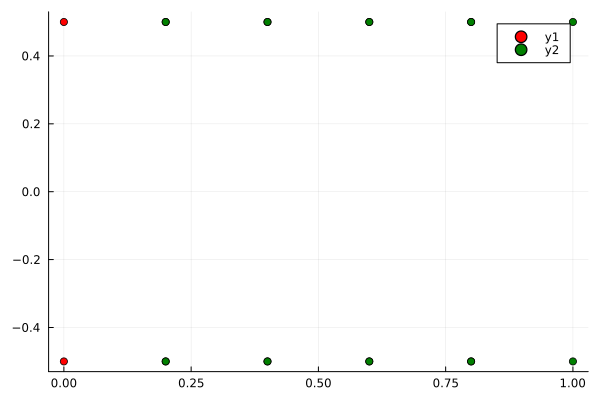

In [48]:
xs, ys, xe, ye = get_capacitance(a,w,n)
using Plots
scatter(xs, ys, mc=:red)
scatter!(xe,ye, mc=:green)


In [44]:
using Printf
@printf("     n      h [m]          C[pF] \n")
for n in [10 20 30 50 70 100 140 200 320]
    @printf("%6d %10.6f %14.10f \n", 
        n, 
        1/(n/2), 
        get_capacitance(1, 1, n))
end

     n      h [m]          C[pF] 
    10   0.200000  18.0313850415 
    20   0.100000  18.3729402299 
    30   0.066667  18.4910121530 
    50   0.040000  18.5869926667 
    70   0.028571  18.6285417541 
   100   0.020000  18.6598668099 
   140   0.014286  18.6808279151 
   200   0.010000  18.6965895465 
   320   0.006250  18.7104096596 


In [45]:
using Polynomials

function estimate_p(h, I)
    return log((I[end-2] - I[end-1])/(I[end-1] - I[end]))/log(h[end-2]/h[end-1])
end

n_vals = [5; 10; 20; 40; 80; 160]
h = 0.01./n_vals
C = [get_capacitance(1, 1, n) for n in n_vals]

p = estimate_p(h, C)
println("Estimated order of convergence: ", p)
pfit = fit(h.^p, C, 1)

Estimated order of convergence: 0.9858747991919479


Polynomial(18.767310010383646 - 740.0749416694081*x)

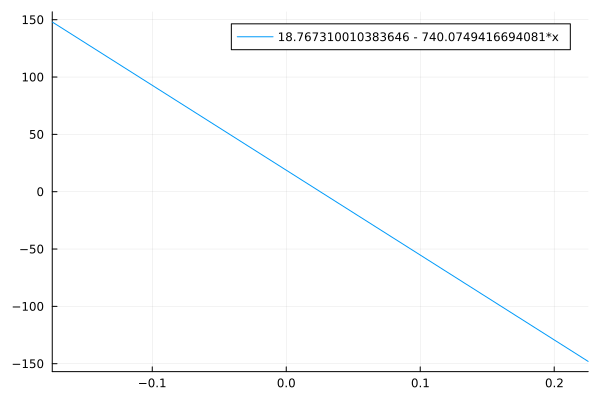

In [46]:
using Plots
plot(pfit)